In [13]:
from getpass import getpass
import os

os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

Enter your OpenAI API key: ··········


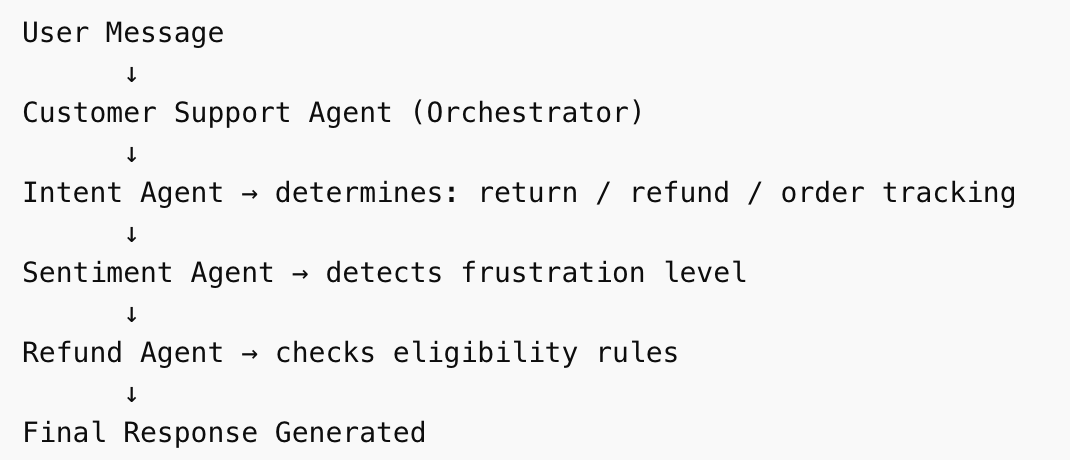

In [2]:
from pydantic import BaseModel

class IntentOutput(BaseModel):
    intent: str
    reasoning: str


class SentimentOutput(BaseModel):
    sentiment: str
    confidence: float


class RefundEligibilityOutput(BaseModel):
    eligible: bool
    reason: str

### **Create Specialist Agents**

In [4]:
!pip install openai-agents

In [6]:
import asyncio
from pydantic import BaseModel
from agents import Agent, Runner

In [15]:
intent_agent = Agent(
    name="Intent Classifier Agent",
    instructions="""
    Classify the user intent into one of:
    - return_request
    - refund_request
    - order_status
    - complaint

    Return structured output.
    """,
    output_type=IntentOutput,   # ← THIS IS REQUIRED
)

In [16]:
sentiment_agent = Agent(
    name="Sentiment Analysis Agent",
    instructions="""
    Analyze the sentiment.
    Return:
    - positive
    - neutral
    - negative
    With confidence score between 0 and 1.
    """,
    output_type=SentimentOutput,
)

In [17]:
refund_agent = Agent(
    name="Refund Eligibility Agent",
    instructions="""
    Determine refund eligibility.
    Damaged product = eligible.
    Return structured reasoning.
    """,
    output_type=RefundEligibilityOutput,
)

In [18]:
async def ecommerce_support_workflow(user_message: str):

    print("\nUser Message:")
    print(user_message)

    # Run Intent + Sentiment in parallel (real-world optimization)
    intent_task = Runner.run(intent_agent, user_message)
    sentiment_task = Runner.run(sentiment_agent, user_message)

    intent_result, sentiment_result = await asyncio.gather(
        intent_task,
        sentiment_task,
    )

    intent_output = intent_result.final_output
    sentiment_output = sentiment_result.final_output

    print("\nIntent Output:", intent_output)
    print("Sentiment Output:", sentiment_output)

    # Conditional A2A delegation
    if intent_output.intent in ["return_request", "refund_request"]:

        refund_result = await Runner.run(refund_agent, user_message)
        refund_output = refund_result.final_output

        print("Refund Eligibility:", refund_output)

        if refund_output.eligible:
            final_response = (
                "We sincerely apologize for the inconvenience. "
                "Your refund request has been approved."
            )
        else:
            final_response = (
                "We reviewed your request. Unfortunately, it is not eligible for refund. "
                + refund_output.reason
            )

    else:
        final_response = (
            "Your request has been routed to the appropriate department."
        )

    print("\nFinal Response:")
    print(final_response)

    return final_response

In [19]:
async def main():

    await ecommerce_support_workflow(
        "I want to return my shoes. They were damaged and I am very unhappy."
    )

    print("\n" + "="*60 + "\n")

    await ecommerce_support_workflow(
        "Where is my order? I placed it last week."
    )


await main()


User Message:
I want to return my shoes. They were damaged and I am very unhappy.

Intent Output: intent='return_request' reasoning='The user explicitly states they want to return their shoes, mentioning the product is damaged and expressing dissatisfaction. This clearly indicates a return request.'
Sentiment Output: sentiment='negative' confidence=0.96
Refund Eligibility: eligible=True reason='You are eligible for a refund because your shoes arrived damaged, which qualifies under the refund policy for damaged products.'

Final Response:
We sincerely apologize for the inconvenience. Your refund request has been approved.



User Message:
Where is my order? I placed it last week.



Intent Output: intent='order_status' reasoning='The user is asking about the location or status of their order placed last week, indicating a desire for an update on its progress or delivery.'
Sentiment Output: sentiment='negative' confidence=0.85

Final Response:
Your request has been routed to the appropriate department.


### **Agent Handoff.**

In [20]:
from pydantic import BaseModel

class RoutingDecision(BaseModel):
    route_to: str
    reason: str

In [21]:
from agents import Agent

refund_agent = Agent(
    name="Refund Agent",
    instructions="""
    You handle refund and return requests.
    Approve refunds for damaged products.
    Provide professional customer-facing responses.
    """,
)

In [22]:
order_tracking_agent = Agent(
    name="Order Tracking Agent",
    instructions="""
    You handle order tracking questions.
    Provide shipment status and delivery estimates.
    """,
)

In [23]:
complaint_agent = Agent(
    name="Complaint Resolution Agent",
    instructions="""
    You handle customer complaints.
    Apologize and offer resolution steps.
    """,
)

In [24]:
triage_agent = Agent(
    name="Ecommerce Triage Agent",
    instructions="""
    You are the first-line ecommerce assistant.

    Your job:
    - Determine user intent
    - Route to the correct specialist

    Routing Rules:
    - Refund or return → refund_agent
    - Order status → order_tracking_agent
    - Complaint → complaint_agent

    Use handoff when appropriate.
    """,
    handoffs=[refund_agent, order_tracking_agent, complaint_agent],
)

In [25]:
from agents import Runner
import asyncio

async def main():

    print("\n--- Refund Case ---")
    result = await Runner.run(
        triage_agent,
        "I want to return my shoes. They arrived damaged."
    )
    print(result.final_output)

    print("\n--- Order Status Case ---")
    result = await Runner.run(
        triage_agent,
        "Where is my order? I placed it last week."
    )
    print(result.final_output)

    print("\n--- Complaint Case ---")
    result = await Runner.run(
        triage_agent,
        "Your service has been terrible."
    )
    print(result.final_output)


await main()


--- Refund Case ---
I'm very sorry to hear that your shoes arrived damaged. I can assist you with your return and refund.

To proceed, could you please provide:
- Your order number
- A photo of the damaged shoes (if possible)

Once I have this information, I will immediately start the refund process for you. Thank you for your understanding, and I apologize for any inconvenience this has caused.

--- Order Status Case ---


I'll help you track your order! Could you please provide your order number or the email address you used when placing the order? This will help me locate your shipment and provide you with the latest status and delivery estimate.

--- Complaint Case ---
I'm very sorry to hear that you've had a terrible experience with our service. Your feedback is important to us, and I apologize for any inconvenience caused.

To help resolve this, could you please share more details about what went wrong? I’m here to assist you and will do my best to make things right. Thank you for bringing this to our attention.
